In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib
from pathlib import Path
from sklearn.metrics import confusion_matrix

In [7]:
y_test = np.load('../data/processed/y_test.npy')
X_test_scaled = np.load('../data/processed/X_test_scaled.npy')

knn_final = joblib.load('../models/knn_model.pkl')
rf_final = joblib.load('../models/rf_model.pkl')
y_pred_knn  = knn_final.predict(X_test_scaled)
y_pred_rf = rf_final.predict(X_test_scaled)


### Summery table

In [8]:
results = {
    'Model':['KNN','Random Forest'],
    'Accuracy':[0.8375,0.9175],
    'Macro F1':[0.84,0.92],
    'Best Parameters':['K=36,weights = distance',
                       'n_estimators=100,max_depth=20']
}

import pandas as pd
df_results = pd.DataFrame(results)
print(df_results)

           Model  Accuracy  Macro F1                Best Parameters
0            KNN    0.8375      0.84        K=36,weights = distance
1  Random Forest    0.9175      0.92  n_estimators=100,max_depth=20


### Visualization

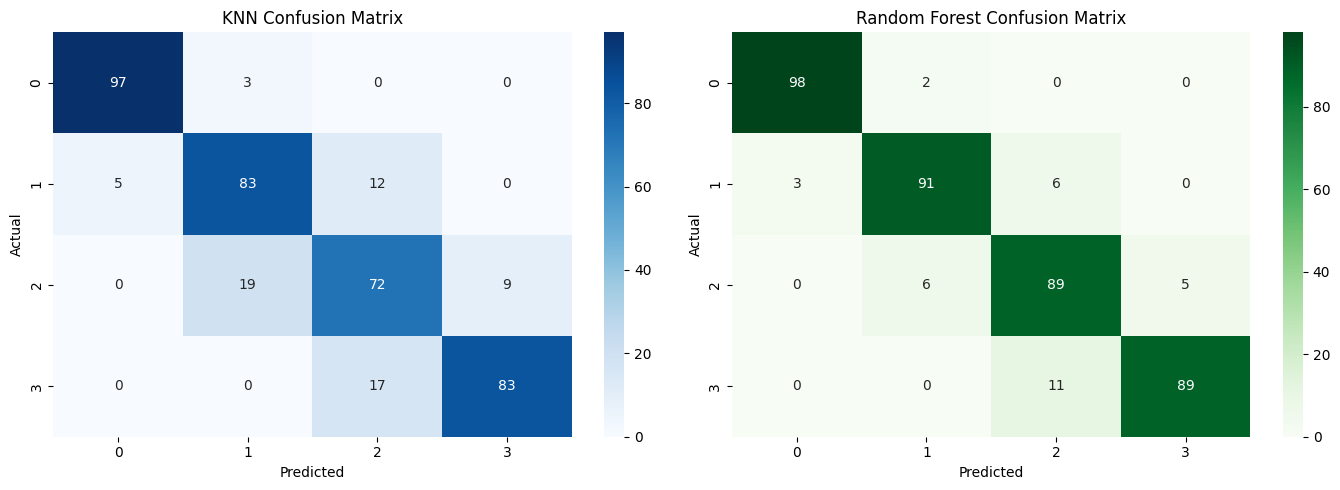

In [9]:
fig,axes = plt.subplots(1,2,figsize=(14,5))

# KNN confusion matrix
cm_knn = confusion_matrix(y_test,y_pred_knn)
sns.heatmap(cm_knn,annot=True,fmt='d',
            cmap='Blues',ax = axes[0])
axes[0].set_title('KNN Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# RF confusion matrix
cm_rf = confusion_matrix(y_test,y_pred_rf)
sns.heatmap(cm_rf,annot=True,fmt='d',
            cmap='Greens',ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

